# Optical forces

Calculating optical forces involves integrating the Maxwell stress tensor (MST) over a closed surface surrounding the region where the force is to be evaluated.

In the frequency domain, the **time-averaged Maxwell stress tensor** is defined as

$$ \langle T_{ij} \rangle = \frac{1}{2}\operatorname{Re}\!\left[\epsilon E_i E_j^* + \mu H_i H_j^* - \frac{1}{2}\left(\epsilon |\mathbf{E}|^2 + \mu |\mathbf{H}|^2\right)\delta_{ij}\right] $$


where $\mathbf{E}$ and $\mathbf{H}$ are the complex electric and magnetic fields, $\epsilon$ and $\mu$ are the permittivity and permeability of the medium, and $\delta_{ij}$ is the Kronecker delta.

The total time-averaged force acting on the enclosed object is obtained by integrating the MST over a closed surface $S$,

$$
\mathbf{F}
=
\oint_S
\langle \mathbf{T} \rangle \cdot \hat{\mathbf{n}} \, dS,
$$

where $\hat{\mathbf{n}}$ is the outward-pointing surface normal.

In Tidy3D, one can define eight [`FluxMonitor`s]([text](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FluxMonitor.html)) surrounding the region of interest to form this closed surface and evaluate the surface integrals numerically.

In this notebook, we demonstrate the complete workflow:

[1)](#1) Define auxiliary functions to generate the surface monitors around the region of interest, compute the MST, and evaluate the resulting force vector.

[2)](#2) Validate the force calculation using a plane wave incident on a dielectric interface.

[3)](#3) Compute the optical forces associated with the symmetric and antisymmetric modes of coupled waveguides, reproducing the results presented in  
   Michelle L. Povinelli, Marko Lončar, Mihai Ibanescu, Elizabeth J. Smythe, Steven G. Johnson, Federico Capasso, and John D. Joannopoulos, *“Evanescent-wave bonding between optical waveguides”*, Optics Letters **30**(22), 2005. [DOI: https://doi.org/10.1364/OL.30.003042](https://opg.optica.org/ol/abstract.cfm?uri=ol-30-22-3042)


<img src="img/opticalForces.png" width="500" alt="Schematic">


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.mode import ModeSolver

## Auxiliary Functions <a name="1"></a>

### Creating Surface Monitors

Now, we will define a function to create eight [FieldMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.FieldMonitor.html) objects around the region of interest.

In [2]:
def surface_mon(center, size, freqs):
    """Create paired field and permittivity monitors on the six faces of a box."""

    mons = []

    size = np.array(size, dtype=float)
    center = np.array(center, dtype=float)

    # Map axis labels to array indices for easy access.
    axis = {"x": 0, "y": 1, "z": 2}

    # Unit vectors along each Cartesian axis, used to translate monitor centers.
    normal = {
        "x": np.array([1, 0, 0]),
        "y": np.array([0, 1, 0]),
        "z": np.array([0, 0, 1]),
    }

    # Mask describing which dimensions should span each face monitor.
    mask = {
        "x": np.array([0, 1, 1]),
        "y": np.array([1, 0, 1]),
        "z": np.array([1, 1, 0]),
    }

    for c in ["x", "y", "z"]:
        i = axis[c]

        for d in [1, -1]:
            # Position the monitor on the +/- face along axis c.
            center_mon = tuple(center + d * normal[c] * size[i] / 2)
            size_mon = tuple(size * mask[c])

            name = f"{c}{'+' if d == 1 else '-'}"

            mons.append(
                td.FieldMonitor(
                    center=center_mon,
                    size=size_mon,
                    name=name,
                    freqs=freqs,
                    colocate=False,
                )
            )

            # Include matching permittivity monitor so material data is available
            # when evaluating the Maxwell stress tensor.
            mons.append(
                td.PermittivityMonitor(
                    center=center_mon,
                    size=size_mon,
                    name=f"e_{name}",
                    freqs=freqs,
                )
            )

    return mons

### Maxwell Stress Tensor Calculation

Now, we will define a function to compute the Maxwell Stress Tensor from a Tidy3D [SimulationData](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.components.data.sim_data.SimulationData.html) object, using the monitors defined by the `surface_mon` function.

In [3]:
def stressTensor(sim_data, monitor_name, eps_mon):
    """Compute the Maxwell stress tensor on the plane defined by `monitor_name`, following the naming convention of the `surface_mon` function."""

    if monitor_name[0] == "x":
        i, j = ("y", "z")

        Ex = sim_data[monitor_name].Ex[:, 1:-1, 1:-1, :]
        Ey = sim_data[monitor_name].Ey[:, 1:-1, 1:-1, :]
        Ez = sim_data[monitor_name].Ez[:, 1:-1, 1:-1, :]

        Hx = sim_data[monitor_name].Hx[:, 1:-1, 1:-1, :]
        Hy = sim_data[monitor_name].Hy[:, 1:-1, 1:-1, :]
        Hz = sim_data[monitor_name].Hz[:, 1:-1, 1:-1, :]

        # Interpolate permittivity onto the field grid covering this face.
        eps_xx = sim_data[eps_mon].eps_xx.interp(y=Ex.coords[i], z=Ex.coords[j])
        eps_yy = sim_data[eps_mon].eps_yy.interp(y=Ey.coords[i], z=Ey.coords[j])
        eps_zz = sim_data[eps_mon].eps_zz.interp(y=Ez.coords[i], z=Ez.coords[j])

    elif monitor_name[0] == "y":
        i, j = ("x", "z")

        Ex = sim_data[monitor_name].Ex[1:-1, :, 1:-1, :]
        Ey = sim_data[monitor_name].Ey[1:-1, :, 1:-1, :]
        Ez = sim_data[monitor_name].Ez[1:-1, :, 1:-1, :]

        Hx = sim_data[monitor_name].Hx[1:-1, :, 1:-1, :]
        Hy = sim_data[monitor_name].Hy[1:-1, :, 1:-1, :]
        Hz = sim_data[monitor_name].Hz[1:-1, :, 1:-1, :]

        eps_xx = sim_data[eps_mon].eps_xx.interp(x=Ex.coords[i], z=Ex.coords[j])
        eps_yy = sim_data[eps_mon].eps_yy.interp(x=Ey.coords[i], z=Ey.coords[j])
        eps_zz = sim_data[eps_mon].eps_zz.interp(x=Ez.coords[i], z=Ez.coords[j])

    elif monitor_name[0] == "z":
        i, j = ("x", "y")

        Ex = sim_data[monitor_name].Ex[1:-1, 1:-1, :, :]
        Ey = sim_data[monitor_name].Ey[1:-1, 1:-1, :, :]
        Ez = sim_data[monitor_name].Ez[1:-1, 1:-1, :, :]

        Hx = sim_data[monitor_name].Hx[1:-1, 1:-1, :, :]
        Hy = sim_data[monitor_name].Hy[1:-1, 1:-1, :, :]
        Hz = sim_data[monitor_name].Hz[1:-1, 1:-1, :, :]

        eps_xx = sim_data[eps_mon].eps_xx.interp(x=Ex.coords[i], y=Ex.coords[j])
        eps_yy = sim_data[eps_mon].eps_yy.interp(x=Ey.coords[i], y=Ey.coords[j])
        eps_zz = sim_data[eps_mon].eps_zz.interp(x=Ez.coords[i], y=Ez.coords[j])

    coords = [Ex.x.squeeze(), Ex.y.squeeze(), Ex.z.squeeze()]

    # Convert xarray data to numpy arrays.
    Ey = Ey.values
    Ez = Ez.values
    Hx = Hx.values
    Hy = Hy.values
    Hz = Hz.values
    eps_xx = eps_xx.values
    eps_yy = eps_yy.values
    eps_zz = eps_zz.values

    # Displacement (D) and magnetic flux (B) densities.
    Dx = Ex * eps_xx * td.EPSILON_0
    Dy = Ey * eps_yy * td.EPSILON_0
    Dz = Ez * eps_zz * td.EPSILON_0

    Bx = Hx * td.MU_0
    By = Hy * td.MU_0
    Bz = Hz * td.MU_0

    # Scalar energy-density terms appearing in the stress tensor formula.
    E_mod = Ex * np.conj(Dx) + Ey * np.conj(Dy) + Ez * np.conj(Dz)
    H_mod = Hx * np.conj(Bx) + Hy * np.conj(By) + Hz * np.conj(Bz)

    # Maxwell stress tensor components prior to taking the real (time-averaged) part.
    Txx = (Ex * np.conj(Dx) - 0.5 * E_mod) + (Hx * np.conj(Bx) - 0.5 * H_mod)
    Txy = (Ex * np.conj(Dy)) + (Hx * np.conj(By))
    Txz = (Ex * np.conj(Dz)) + (Hx * np.conj(Bz))

    Tyy = (Ey * np.conj(Dy) - 0.5 * E_mod) + (Hy * np.conj(By) - 0.5 * H_mod)
    Tyx = (Ey * np.conj(Dx)) + (Hy * np.conj(Bx))
    Tyz = (Ey * np.conj(Dz)) + (Hy * np.conj(Bz))

    Tzz = (Ez * np.conj(Dz) - 0.5 * E_mod) + (Hz * np.conj(Bz) - 0.5 * H_mod)
    Tzx = (Ez * np.conj(Dx)) + (Hz * np.conj(Bx))
    Tzy = (Ez * np.conj(Dy)) + (Hz * np.conj(By))

    T = np.array([[Txx, Txy, Txz], [Tyx, Tyy, Tyz], [Tzx, Tzy, Tzz]])

    # Time-average via the real part and include the 1/2 prefactor.
    return 0.5 * T.real, coords

### Force Calculation

Finally, we will define a function to integrate all monitors from a [SimulationData](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.components.data.sim_data.SimulationData.html) object and compute the force vector.

In [4]:
def integrateStressTensor(sim_data):
    """Integrate the Maxwell stress tensor over a closed box of monitors."""

    Fx_x = Fy_x = Fz_x = 0.0
    Fx_y = Fy_y = Fz_y = 0.0
    Fx_z = Fy_z = Fz_z = 0.0

    for c in ["x", "y", "z"]:
        for d in [1, -1]:
            name = c + ("+" if d == 1 else "-")
            T, coords = stressTensor(sim_data, name, "e_" + name)

            if c == "x":
                # Extract tensor components T_{ix} on the x± faces.
                Txx = T[0, 0].squeeze()
                Tyx = T[1, 0].squeeze()
                Tzx = T[2, 0].squeeze()

                iy = np.argsort(coords[1])
                iz = np.argsort(coords[2])

                y_sorted = np.asarray(coords[1])[iy]
                z_sorted = np.asarray(coords[2])[iz]

                Txx = Txx[iy][:, iz]
                Tyx = Tyx[iy][:, iz]
                Tzx = Tzx[iy][:, iz]

                Fx_x += d * np.trapezoid(np.trapezoid(Txx, y_sorted, axis=0), z_sorted, axis=0)
                Fy_x += d * np.trapezoid(np.trapezoid(Tyx, y_sorted, axis=0), z_sorted, axis=0)
                Fz_x += d * np.trapezoid(np.trapezoid(Tzx, y_sorted, axis=0), z_sorted, axis=0)

            elif c == "y":
                # Integrate T_{iy} over the y± faces.
                Txy = T[0, 1].squeeze()
                Tyy = T[1, 1].squeeze()
                Tzy = T[2, 1].squeeze()

                ix = np.argsort(coords[0])
                iz = np.argsort(coords[2])

                x_sorted = np.asarray(coords[0])[ix]
                z_sorted = np.asarray(coords[2])[iz]

                Txy = Txy[ix][:, iz]
                Tyy = Tyy[ix][:, iz]
                Tzy = Tzy[ix][:, iz]

                Fx_y += d * np.trapezoid(np.trapezoid(Txy, x_sorted, axis=0), z_sorted, axis=0)
                Fy_y += d * np.trapezoid(np.trapezoid(Tyy, x_sorted, axis=0), z_sorted, axis=0)
                Fz_y += d * np.trapezoid(np.trapezoid(Tzy, x_sorted, axis=0), z_sorted, axis=0)

            elif c == "z":
                # Integrate T_{iz} over the z± faces.
                Txz = T[0, 2].squeeze()
                Tyz = T[1, 2].squeeze()
                Tzz = T[2, 2].squeeze()

                ix = np.argsort(coords[0])
                iy = np.argsort(coords[1])

                x_sorted = np.asarray(coords[0])[ix]
                y_sorted = np.asarray(coords[1])[iy]

                Txz = Txz[ix][:, iy]
                Tyz = Tyz[ix][:, iy]
                Tzz = Tzz[ix][:, iy]

                Fx_z += d * np.trapezoid(np.trapezoid(Txz, x_sorted, axis=0), y_sorted, axis=0)
                Fy_z += d * np.trapezoid(np.trapezoid(Tyz, x_sorted, axis=0), y_sorted, axis=0)
                Fz_z += d * np.trapezoid(np.trapezoid(Tzz, x_sorted, axis=0), y_sorted, axis=0)

    # Sum contributions from all faces and apply the outward normal convention.
    Fx = Fx_x + Fx_y + Fx_z
    Fy = Fy_x + Fy_y + Fy_z
    Fz = Fz_x + Fz_y + Fz_z

    return Fx, Fy, Fz

## Force at a Planar Interface With Oblique Incidence <a name="2"></a>

Consider an incident plane wave in medium 1 (index $n_1$) impinging on a planar interface with medium 2 (index $n_2$), with incidence angle $\theta_i$ measured from the surface normal $\hat{\mathbf{n}}$ pointing from medium 1 to medium 2. With no absorption, the net time-averaged **normal** force comes from the change in normal momentum flux of the incident, reflected, and transmitted waves.

If $I$ is the incident intensity in medium 1, and $R,T$ are the **power** reflectance/transmittance (so $R+T=1$), then the normal force on an illuminated area $A$ can be written as

$$
F_{normal} \;=\; \frac{I\,A}{c_0}\Big[\cos(\theta_i)\,(1+R)\;-\;n_2\,\cos(\theta_t)\,T\Big].
$$

To implement this in Tidy3D, we will create a function that generates the simulation object as a function of the permittivity of medium 2 and the incident angle. We will define a simple simulation with [PlaneWave](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PlaneWave.html) excitation and Bloch boundary conditions. To create the monitors, we will use the predefined

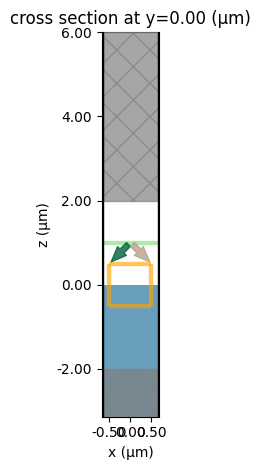

In [5]:
wl = 1
freq0 = td.C_0 / 1
fwidth = 0.1 * freq0


def getSim(theta, permittivity=3.5**2, direction="z", min_steps_per_wvl=20):
    """Build a planar-scattering simulation for a slab and surrounding monitors."""

    plane_size = 1.3

    medium = td.Medium(permittivity=permittivity)

    # Frequencies to sample (single point for steady-state response).
    freqs = [freq0]

    # Convert incidence and polarization angles to radians.
    theta_rad = np.deg2rad(theta)

    # Select injection plane and Bloch axes depending on propagation direction.
    if direction == "z":
        center = (0, 0, 1)
        size = [td.inf, td.inf, 0]
        axis_1 = 0
        axis_2 = 1

    elif direction == "y":
        center = (0, 1, 0)
        size = [td.inf, 0, td.inf]
        axis_1 = 0
        axis_2 = 2

    elif direction == "x":
        center = (1, 0, 0)
        size = [0, td.inf, td.inf]
        axis_1 = 1
        axis_2 = 2

    # Define the incident plane wave illumination.
    planewave_0 = td.PlaneWave(
        size=size,
        center=center,
        source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
        direction="-",
        angle_theta=theta_rad,
    )

    # Bloch boundaries.
    bloch_1 = td.Boundary.bloch_from_source(
        source=planewave_0, domain_size=plane_size, axis=axis_1, medium=td.Medium(permittivity=1)
    )

    bloch_2 = td.Boundary.bloch_from_source(
        source=planewave_0, domain_size=plane_size, axis=axis_2, medium=td.Medium(permittivity=1)
    )

    # Create closed surface monitors used later for force calculations.
    surface_mons = surface_mon(center=(0, 0, 0), size=(1, 1, 1), freqs=freqs)

    if direction == "x":
        bspec = td.BoundarySpec(y=bloch_1, z=bloch_2, x=td.Boundary.absorber(num_layers=80))
        center_box = [-55.5, 500, 500]
        size_box = [111, 1222, 1222]
        sim_size = [4, plane_size, plane_size]
    elif direction == "y":
        bspec = td.BoundarySpec(x=bloch_1, z=bloch_2, y=td.Boundary.absorber(num_layers=80))
        center_box = [500, -55.5, 500]
        size_box = [1222, 111, 1222]
        sim_size = [plane_size, 4, plane_size]
    elif direction == "z":
        bspec = td.BoundarySpec(x=bloch_1, y=bloch_2, z=td.Boundary.absorber(num_layers=80))
        center_box = [500, 500, -55.5]
        size_box = [1222, 1222, 111]
        sim_size = [plane_size, plane_size, 4]

    # Slab structure occupying the high-index region.
    box_0 = td.Structure(
        geometry=td.Box(center=center_box, size=size_box), name="box_0", medium=medium
    )

    # Assemble the full simulation with sources, monitors, and structure.
    sim = td.Simulation(
        size=sim_size,
        boundary_spec=bspec,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl),
        run_time=5e-12,
        sources=[planewave_0],
        monitors=surface_mons,
        structures=[box_0],
    )

    return sim


sim = getSim(45)
_ = sim.plot(y=0)

plt.show()

Now we will vary the incidence angle and compare the results with the analytical solution. To test all three directions, we will create three batches, corresponding to plane-wave incidence along the x, y, and z directions.

In [6]:
sims_x = {}
sims_y = {}
sims_z = {}
thetas = [0, 10, 20, 30, 40, 50]
for theta in thetas:
    sims_x[f"{theta}"] = getSim(theta, direction="x")
    sims_y[f"{theta}"] = getSim(theta, direction="y")
    sims_z[f"{theta}"] = getSim(theta, direction="z")

batch_x = web.Batch(simulations=sims_x, folder_name="OpticalForces_x")
batch_data_thetas_x = batch_x.run(path_dir="batchThetas_x")

batch_y = web.Batch(simulations=sims_y, folder_name="OpticalForces_y")
batch_data_thetas_y = batch_y.run(path_dir="batchThetas_y")

batch_z = web.Batch(simulations=sims_z, folder_name="OpticalForces_z")
batch_data_thetas_z = batch_z.run(path_dir="batchThetas_z")

Output()

18:43:28 CEST Started working on Batch containing 6 tasks.

18:44:22 CEST Maximum FlexCredit cost: 1.961 for the whole batch.

              Use 'Batch.real_cost()' to get the billed FlexCredit cost after   
              completion.

Output()

...

18:55:42 CEST Started working on Batch containing 6 tasks.

18:56:33 CEST Maximum FlexCredit cost: 1.961 for the whole batch.

              Use 'Batch.real_cost()' to get the billed FlexCredit cost after   
              completion.

Output()

18:58:55 CEST Batch complete.

In [7]:
axes = ["x", "y", "z"]
components = ["Fx", "Fy", "Fz"]

# Pre-allocate containers for the force components keyed by face axis.
forces = {axis: {comp: [] for comp in components} for axis in axes}

for theta_key in batch_data_thetas_x.keys():
    print(theta_key)

    # Evaluate the stress tensor on each pair of monitors.
    evaluations = {
        "x": integrateStressTensor(batch_data_thetas_x[theta_key]),
        "y": integrateStressTensor(batch_data_thetas_y[theta_key]),
        "z": integrateStressTensor(batch_data_thetas_z[theta_key]),
    }

    # Append the results to the appropriate component lists.
    for axis, (fx_val, fy_val, fz_val) in evaluations.items():
        for comp, value in zip(components, (fx_val, fy_val, fz_val)):
            forces[axis][comp].append(np.array(value))

# Unpack back into the original variable names for downstream cells.
FxT_x, FyT_x, FzT_x = forces["x"]["Fx"], forces["x"]["Fy"], forces["x"]["Fz"]
FxT_y, FyT_y, FzT_y = forces["y"]["Fx"], forces["y"]["Fy"], forces["y"]["Fz"]
FxT_z, FyT_z, FzT_z = forces["z"]["Fx"], forces["z"]["Fy"], forces["z"]["Fz"]

0
10
20
30
40
50


Now we will define the analytical function. Note that the [PlaneWave](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PlaneWave.html) source is normalized to inject 1 W of power. Therefore, the total power crossing the monitor area must be corrected by the simulation plane size. More information on source normalization can be found [here](https://docs.flexcompute.com/projects/tidy3d/en/latest/faq/docs/faq/How-are-results-normalized.html).

In [8]:
def interface_force_eps(eps, I=1, A=1, theta_i=0):
    import numpy as np

    theta_i = np.deg2rad(theta_i)
    n1 = 1.0
    n2 = np.sqrt(eps)

    theta_t = np.arcsin(np.sin(theta_i) / n2)

    # Fresnel power coefficients (TE and TM)
    R = (
        (n2 * np.cos(theta_i) - n1 * np.cos(theta_t))
        / (n2 * np.cos(theta_i) + n1 * np.cos(theta_t))
    ) ** 2

    T = 1 - R  # lossless

    Fz = (I * A / td.C_0) * (np.cos(theta_i) * (1 + R) - n2 * np.cos(theta_t) * T)

    return np.abs(Fz)


# Adjusting the incident intensity to match the simulation results
I0 = (1 / 1.3) ** 2
Fz_a_theta = interface_force_eps(eps=3.5**2, theta_i=np.array(thetas), I=I0)

Now we can visualize the results. The force normal to the incident plane follows the analytical expression for all three directions, and the other components are close to zero, as expected.

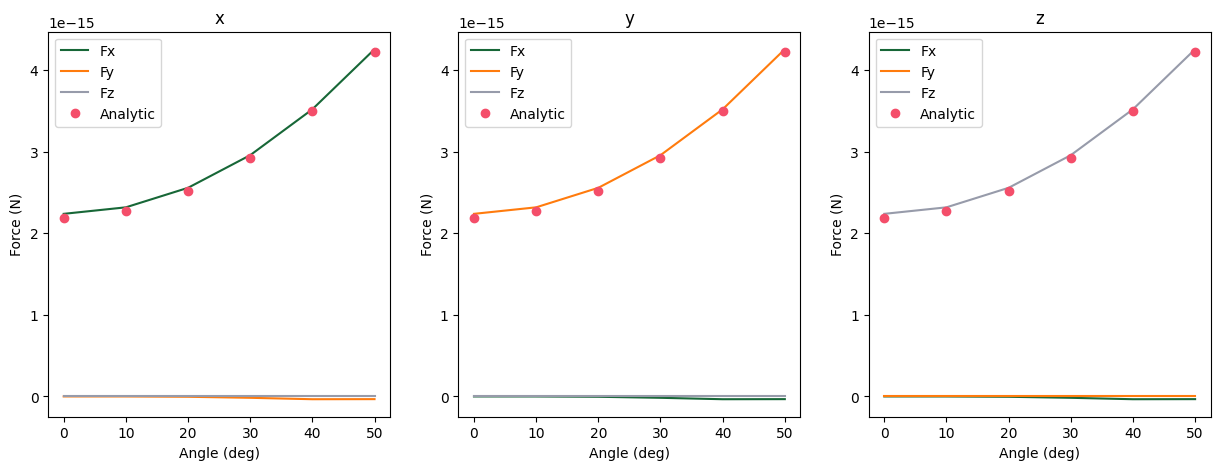

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
axes[0].plot(thetas, np.array([np.sum(i) for i in FxT_x]), label="Fx")
axes[0].plot(thetas, np.array([np.sum(i) for i in FyT_x]), label="Fy")
axes[0].plot(thetas, np.array([np.sum(i) for i in FzT_x]), label="Fz")
axes[0].plot(thetas, np.array(Fz_a_theta), "o", label="Analytic")
axes[0].set_title("x")
axes[0].legend()

axes[1].plot(thetas, np.array([np.sum(i) for i in FxT_y]), label="Fx")
axes[1].plot(thetas, np.array([np.sum(i) for i in FyT_y]), label="Fy")
axes[1].plot(thetas, np.array([np.sum(i) for i in FzT_y]), label="Fz")
axes[1].plot(thetas, np.array(Fz_a_theta), "o", label="Analytic")
axes[1].set_title("y")
axes[1].legend()

axes[2].plot(thetas, np.array([np.sum(i) for i in FxT_z]), label="Fx")
axes[2].plot(thetas, np.array([np.sum(i) for i in FyT_z]), label="Fy")
axes[2].plot(thetas, np.array([np.sum(i) for i in FzT_z]), label="Fz")
axes[2].plot(thetas, np.array(Fz_a_theta), "o", label="Analytic")
axes[2].set_title("z")
axes[2].legend()


for ax in axes:
    ax.set_xlabel("Angle (deg)")
    ax.set_ylabel("Force (N)")


plt.show()

## Force in Coupled Waveguides <a name="3"></a>

Next, we calculate the attraction and repulsion forces in a system of two coupled waveguides, as described in the [reference paper](https://opg.optica.org/ol/abstract.cfm?uri=ol-30-22-3042).

The system consists of two square waveguides with size $a = 0.31$ µm and varying separation $d$. Two types of modes can be supported: symmetric modes (same $E_z$ field sign in both waveguides) and antisymmetric modes (opposite signs).

We will define a function to create the setup based on the separation $d$, add a surface monitor around one of the waveguides, and calculate the net force in the direction perpendicular to the waveguides.

In [10]:
from typing import List, Optional


def build_double_waveguide_sim(
    a: float = 0.310,
    d: float = 0.25,
    wavelength: float = 1.55,
    wg_medium: Optional[td.Medium] = td.Medium(permittivity=3.45**2),
    x_span: float = 6.0,
    buffer_y: float = 2,
    buffer_z: float = 2,
    source_offset: float = 0.2,
    mode_index=1,
) -> td.Simulation:
    """Create a Tidy3D simulation containing two identical square waveguides"""

    if a <= 0.0:
        raise ValueError("Waveguide size 'a' must be positive.")
    if d < 0.0:
        raise ValueError("Waveguide separation 'd' must be non-negative.")
    if source_offset >= x_span / 2:
        raise ValueError("Source offset must be smaller than half of the simulation span.")

    # Distance from simulation centre to each waveguide centre along y.
    half_center_sep = 0.5 * (a + d)
    waveguide_centers: List[float] = [-half_center_sep, half_center_sep]

    # Simulation extents along each dimension (µm).
    y_half_span = a + d / 2 + buffer_y
    z_half_span = a / 2 + buffer_z
    sim_size = (x_span, 2 * y_half_span, 2 * z_half_span)

    structures = [
        td.Structure(
            geometry=td.Box(center=(0.0, yc, 0.0), size=(td.inf, a, a)),
            medium=wg_medium,
        )
        for yc in waveguide_centers
    ]

    freq0 = td.C_0 / wavelength
    pulse = td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10)
    source_x = -0.5 * x_span + source_offset

    sources = [
        td.ModeSource(
            center=(source_x, 0, 0.0),
            size=(0.0, td.inf, td.inf),
            source_time=pulse,
            direction="+",
            mode_spec=td.ModeSpec(num_modes=4),
            mode_index=mode_index,
        )
    ]

    sim = td.Simulation(
        size=sim_size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=50),
        structures=structures,
        sources=sources,
        run_time=5e-12,
        monitors=surface_mon(
            center=(0, (d / 2 + a / 2 + 0.5), 0), size=(1, a + d / 2 + 1, 1), freqs=[freq0]
        ),
        symmetry=(0, 0, -1),
    )

    ms = ModeSolver(
        simulation=sim,
        plane=sources[0].bounding_box,
        freqs=[sources[0].source_time.freq0],
        mode_spec=sources[0].mode_spec,
    )

    return sim, ms


sim, ms = build_double_waveguide_sim(d=0.1)

First, we will run a mode solver simulation to identify the effective indices of the symmetric and antisymmetric modes.

In [11]:
mode_data = web.run(ms, "mode")

18:59:02 CEST Created task 'mode' with resource_id                              
              'mo-d547184e-2d93-47b1-837a-957f5b45fb76' and task_type           
              'MODE_SOLVER'.

              View task using web UI at                                         
              ]8;id=34293;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=777597;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\taskId]8;;\]8;id=34293;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\=]8;;\]8;id=344951;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\mo]8;;\]8;id=34293;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\-d547184e-2d93]8;;\
              ]8;id=34293;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\-47b1-837a-957f5b45fb76']8;;\.

              Task folder: ]8;id=967276;https://tidy3d.simulation.cloud/folders/9b36e144-ddb6-41f8-8dd8-30b62b26a870\'default']8;;\.

Output()

18:59:11 CEST Estimated FlexCredit cost: 0.004. Minimum cost depends on task    
              execution details. Use 'web.real_cost(task_id)' to get the billed 
              FlexCredit cost after a simulation run.

...

18:59:22 CEST running solver

18:59:25 CEST status = success

              View simulation result at                                         
              ]8;id=903142;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=41222;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\taskId]8;;\]8;id=903142;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\=]8;;\]8;id=70979;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\mo]8;;\]8;id=903142;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\-d547184e-2d93]8;;\
              ]8;id=903142;https://tidy3d.simulation.cloud/workbench?taskId=mo-d547184e-2d93-47b1-837a-957f5b45fb76\-47b1-837a-957f5b45fb76']8;;\.

Output()

18:59:28 CEST Loading results from simulation_data.hdf5

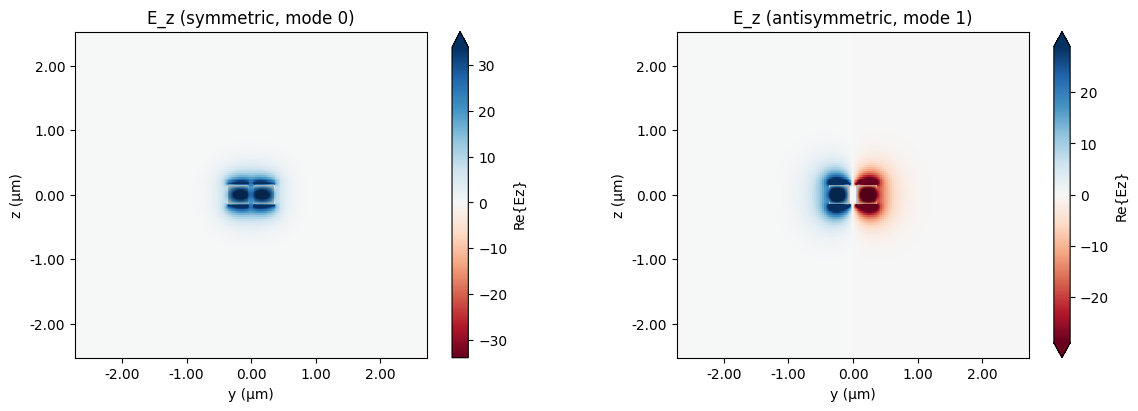

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for ax, (mode_index, title) in zip(
    axes,
    [
        (0, "E_z (symmetric, mode 0)"),
        (1, "E_z (antisymmetric, mode 1)"),
    ],
):
    ms.plot_field("Ez", "real", mode_index=mode_index, ax=ax)
    ax.set_title(title)

# 0 → symmetric fundamental mode
# 1 → antisymmetric higher-order mode

plt.show()

Next, we will sweep the values of $d$ and create two batch simulations for each symmetry.

In [13]:
d_values = np.linspace(0.03, 0.31, 21)
sims_1 = {str(i): build_double_waveguide_sim(d=i, mode_index=0)[0] for i in d_values}
batch_1 = web.Batch(simulations=sims_1, folder_name="double_waveguide_1")
batch_data_1 = batch_1.run(path_dir="double_waveguide_1")

sims_2 = {str(i): build_double_waveguide_sim(d=i, mode_index=1)[0] for i in d_values}
batch_2 = web.Batch(simulations=sims_2, folder_name="double_waveguide_2")
batch_data_2 = batch_2.run(path_dir="double_waveguide_2")

Output()

18:59:46 CEST Started working on Batch containing 21 tasks.

19:04:35 CEST Maximum FlexCredit cost: 30.901 for the whole batch.

              Use 'Batch.real_cost()' to get the billed FlexCredit cost after   
              completion.

Output()

...

19:05:35 CEST Started working on Batch containing 21 tasks.

19:08:42 CEST Maximum FlexCredit cost: 30.901 for the whole batch.

              Use 'Batch.real_cost()' to get the billed FlexCredit cost after   
              completion.

Output()

19:12:47 CEST Batch complete.

Finally, we calculate the forces for each simulation and plot the y component. 

As we can see, the results closely match Fig. 1(b) of the [reference paper](https://opg.optica.org/ol/abstract.cfm?uri=ol-30-22-3042).

In [14]:
F_1 = [integrateStressTensor(batch_data_1[i]) for i in batch_data_1.keys()]
F_2 = [integrateStressTensor(batch_data_2[i]) for i in batch_data_2.keys()]

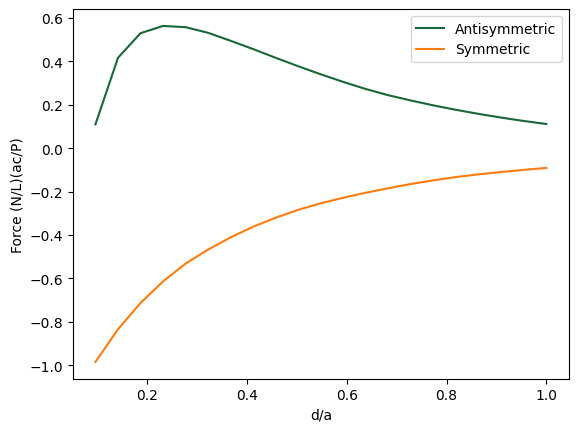

In [15]:
fig, ax = plt.subplots()
factor = 0.31 * td.C_0 / 1  # Source is normalized to 1W
ax.plot(d_values / 0.31, np.array([i[1] for i in F_2]) * factor, label="Antisymmetric")
ax.plot(d_values / 0.31, np.array([i[1] for i in F_1]) * factor, label="Symmetric")
ax.set_xlabel("d/a")
ax.set_ylabel("Force (N/L)(ac/P)")

ax.legend()
plt.show()